In [1]:
###########    Prediction fine tuned model ################

import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import classification_report, accuracy_score
import sys
sys.path.append(r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper") 
from Analysis_pipeline.intent_train_test_preprocess import preprocess

# Labels used during training (order must match model head)
labels = ['Appreciation', 'Criticism', 'Inquiry', 'Statement']

# Load data once
data = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v3\generated_comments_v3.csv")
preprocessed_texts = [preprocess(text) for text in data["generated_comment"]]
d = pd.DataFrame({"text": preprocessed_texts})
d = d.apply(lambda row: f"{row['text']}", axis=1).tolist()
Comments = data['generated_comment']
# Helper to infer on one model and return a dataframe with logits/probs per label
def run_model_and_collect(model_dir, tok_dir, model_tag, texts, labels, batch_size=32, max_length=512):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(device)
    tokenizer = AutoTokenizer.from_pretrained(tok_dir, use_fast=False)
    model.eval()

    # Storage
    predicted_labels = []
    per_label_logits = {lab: [] for lab in labels}
    per_label_probs  = {lab: [] for lab in labels}

    def get_predictions_for_batch(batch_texts):
        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.inference_mode():
            outputs = model(**enc)
            logits_t = outputs.logits.float()                 # (B, L)
            probs_t  = torch.softmax(logits_t, dim=-1)        # (B, L)

        logits = logits_t.cpu().numpy()
        probs  = probs_t.cpu().numpy()
        preds  = probs.argmax(axis=1)
        pred_labels = [labels[i] for i in preds]

        return pred_labels, logits, probs

    # Batched inference
    for i in tqdm(range(0, len(texts), batch_size), desc=f"Predicting ({model_tag})"):
        batch_texts = texts[i:i+batch_size]
        batch_pred_labels, batch_logits, batch_probs = get_predictions_for_batch(batch_texts)

        predicted_labels.extend(batch_pred_labels)
        # Accumulate per-label scores
        for row_idx in range(len(batch_texts)):
            for j, lab in enumerate(labels):
                per_label_logits[lab].append(float(batch_logits[row_idx][j]))
                per_label_probs[lab].append(float(batch_probs[row_idx][j]))

    # Build dataframe for this model
    df = pd.DataFrame({"Comments": Comments})
    df["Labels"] = predicted_labels
    # Add per-label columns with model tag prefix
    for lab in labels:
        df[f"{model_tag}_logit_{lab}"] = per_label_logits[lab]
        df[f"{model_tag}_prob_{lab}"]  = per_label_probs[lab]

    return df

# Run all three models
models = ["GRONLP_new3_CV", "robert_new3_CV", "debertaV3_new3_CV"]
for model_name in tqdm(models, desc="Loading models"):
    model_output_dir = f"C:\\Users\\20245179\\OneDrive - TU Eindhoven\\LLM_EngD_project\\Intent recognition Comments\\Fine_tuned_4_intents\\real_data_distrubution\\models\\fine_tune_BERT\\intent_fine_tuned_4_intents_{model_name}"
    tokenizer_output_dir = f"C:\\Users\\20245179\\OneDrive - TU Eindhoven\\LLM_EngD_project\\Intent recognition Comments\\Fine_tuned_4_intents\\real_data_distrubution\\models\\fine_tune_BERT\\intent_fine_tuned_4_intents_{model_name}"

    # Short, consistent tag for column names
    tag_map = {
        "GRONLP_new3_CV": "GRO_NLP",
        "robert_new3_CV": "roberta",
        "debertaV3_new3_CV": "debertaV3"
    }
    tag = tag_map[model_name]

    df_model = run_model_and_collect(
        model_dir=model_output_dir,
        tok_dir=tokenizer_output_dir,
        model_tag=tag,
        texts=d,
        labels=labels,
        batch_size=32,
        max_length=512
    )

    if model_name == "GRONLP_new3_CV":
        gro_cross = df_model.copy()
    elif model_name == "robert_new3_CV":
        roberta_cross = df_model.copy()
    elif model_name == "debertaV3_new3_CV":
        debertav3_cross = df_model.copy()

# Combine predictions (and keep per-model logits/probs)
combined_intent_english_fine_tuned = pd.DataFrame({"Comments": gro_cross["Comments"]})

# Predicted labels per model (keep your original column names)
combined_intent_english_fine_tuned["GRO_NLP"] = gro_cross["Labels"]
combined_intent_english_fine_tuned["roberta"] = roberta_cross["Labels"]
combined_intent_english_fine_tuned["debertaV3"] = debertav3_cross["Labels"]

# Append all per-label logits/probs columns from each model
# (They already have distinct prefixes: GRO_NLP_, roberta_, debertaV3_)
for df_src in [gro_cross, roberta_cross, debertav3_cross]:
    extra_cols = [c for c in df_src.columns if c not in ["Comments", "Labels"]]
    combined_intent_english_fine_tuned = combined_intent_english_fine_tuned.join(df_src[extra_cols])

########### Majority Voting 3 models #####################

from collections import Counter

intents = combined_intent_english_fine_tuned.copy()
models_to_consider = ["GRO_NLP", 'roberta', 'debertaV3']

def majority_vote_three_models(row):
    counts = Counter([row[model] for model in models_to_consider])
    most_common = counts.most_common()
    if most_common[0][1] == 3:  # unanimous
        return most_common[0][0]
    elif most_common[0][1] == 2:  # 2/3 majority
        return most_common[0][0]
    else:
        return 'undefined'

intents['final_label_three_models'] = intents.apply(majority_vote_three_models, axis=1)
intents['final_label_three_models_final'] = intents.apply(
    lambda row: row['roberta'] if row['final_label_three_models'] == 'undefined' else row['final_label_three_models'],
    axis=1
)
intents.loc[
    intents['Comments'].str.startswith("<PERSON>"),
    'final_label_three_models_final'
] = 'Forward'

# Save the final DataFrame (now includes logits & probs per intent per model)
intents.to_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v3\intent_predictions.csv", index=False)


: 

C:\Users\20245179\AppData\Local\Temp\ipykernel_28344\1270326075.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=desired_order, y=[label_counts[label] for label in desired_order], palette='viridis')


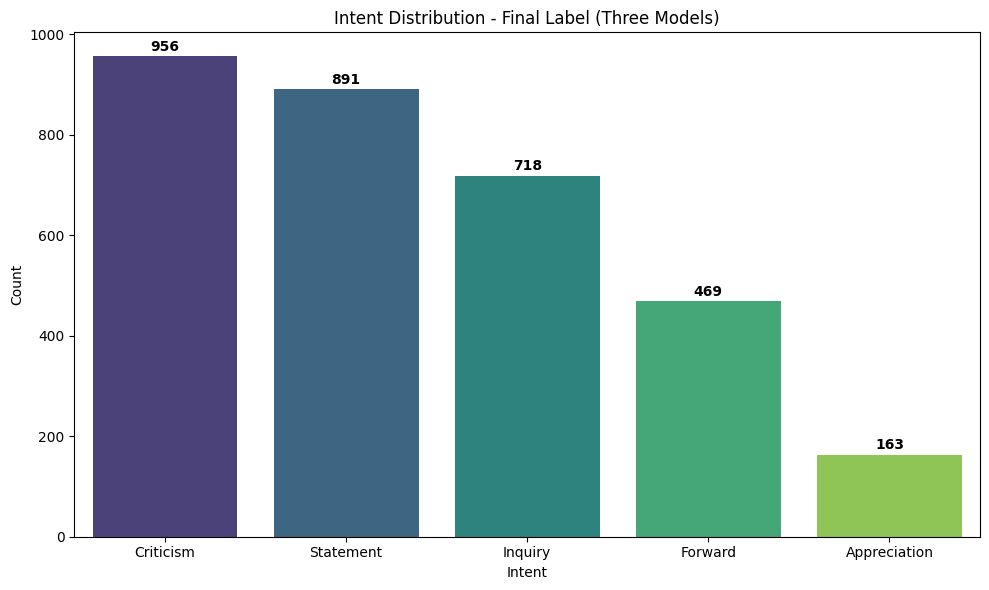

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

intents = pd.read_csv("intent_predictions_fine_tuned_4_intents_real_data_distribution_majority_voting_3_models.csv")
# Count occurrences
label_counts = intents['final_label_three_models_final'].value_counts()

# Optional: Sort labels if needed
desired_order = label_counts.index.tolist()  # Or manually set order

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=desired_order, y=[label_counts[label] for label in desired_order], palette='viridis')

# Add count labels
for bar, count in zip(ax.patches, [label_counts[label] for label in desired_order]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    ax.text(x, y + 5, str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Intent Distribution - Final Label (Three Models)')
plt.xlabel('Intent')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
